# Initialization

Always run those cells before using the notebook, it import needed packages and initialize helper functions.

In [1]:
from classiq import *
from typing import List
import numpy as np
import pandas as pd
from dataclasses import dataclass
from matplotlib import pyplot as plt
import matplotlib
# %matplotlib widget

In [2]:
@dataclass
class params:
    # Algorithm parameters
    l = 0.5
    m = 2
    n = 3
    n0 = 3

    @property
    def N(self):
        return 2**self.n

    @property
    def N0(self):
        return 2**self.n0

    # Function parameters
    f = None
    f_prams = None
    f_name = None

    def set_function(self, f, f_prams):
        self.f_prams = f_prams

        # Allow passing by name, e.g. "linear" or "quadratic"
        if isinstance(f, str):
            self.f_name = f
            self.f = getattr(self, f)
            return

        # If a method from another params instance is passed,
        # re-bind it to this instance to avoid mixed state.
        if hasattr(f, "__func__"):
            self.f = f.__func__.__get__(self, self.__class__)
        else:
            self.f = f

        self.f_name = getattr(self.f, "__name__", None)

    # Generated functions
    def f_normalized(self, x):
        val = self.f(self.l / self.N * (x - self.N // 2))
        val *= self.N / (self.l * self.m)
        return val

    def calculate_magnitude_and_phase(self):
        x_array = np.arange(self.N)
        # reorder the x_array to match the order of the quantum states
        # TODO: delete? x_array = np.concatenate((x_array[self.N//2:], x_array[:self.N//2]))
        phases = self.f_normalized(x_array) * 2 * np.pi
        magnitudes = np.ones(self.N) * 1 / self.N
        return magnitudes, phases

    def analytical_gradient(self, x):
        if self.f_name == 'linear':
            return self.f_prams[0]
        elif self.f_name == 'quadratic':
            return (2 * self.f_prams[0] * x + self.f_prams[1])
        else:
            raise NotImplementedError("Analytical gradient not implemented for this function.")

    # A few example functions
    def linear(self, x):
        return self.f_prams[0] * x + self.f_prams[1]

    def quadratic(self, x):
        return self.f_prams[0] * x**2 + self.f_prams[1] * x + self.f_prams[2]

    # Unpack function, to be used in the notebook
    def unpack(self):
        global l, m, n, n0, f, f_prams, N, N0
        l, m, n, n0, N, N0 = self.l, self.m, self.n, self.n0, self.N, self.N0
        f, f_prams = self.f, self.f_prams
        global f_normalized
        f_normalized = self.f_normalized

In [3]:
# ****** Simulation ******
def run_statevector_simulation(qfunc_to_run, print_circuit_info=False, filter_ancilla=False):
    # Run a statevector simulator
    qprog = synthesize(qfunc_to_run)
    #show(qprog)
    if print_circuit_info:
        print("Circuit Width:", qprog.data.width)
        print("Circuit Depth:", qprog.transpiled_circuit.depth)
        print("Gate Counts:", qprog.transpiled_circuit.count_ops)

    backend_preferences = ClassiqBackendPreferences(backend_name="simulator_statevector")
    execution_preferences = ExecutionPreferences(num_shots=1, backend_preferences=backend_preferences)
    with ExecutionSession(qprog, execution_preferences=execution_preferences) as es:
        if filter_ancilla:
            es.set_measured_state_filter("ancilla", lambda v: v == 0)
        results_statevector = es.sample()
    df = results_statevector.dataframe
    return df

def run_standard_simulation(qfunc_to_run):
    # Run a regular simulator
    qprog = synthesize(qfunc_to_run)
    job = execute(qprog)
    # job.open_in_ide()
    pc = job.get_sample_result().parsed_counts
    return pc

# ****** Result Processing ******
def state_to_gradient(value):
    if value >= N//2:
        value -= N
    return value / (N/m)

def simplify_df(df, unwrap=True):
    # Get the phase from the df
    phases = np.angle(df["amplitude"]).astype(float)
    phases_over_2pi = phases/(2*np.pi)
    f_classical = f_normalized(df['x'])
    simplified_df = pd.DataFrame({"f_classical": f_classical, "phase_over_2pi": phases_over_2pi.round(5)})
    simplified_df.index = df['x']
    simplified_df.sort_index(inplace=True)

    # Unwrap the phase if requested
    if unwrap:
        # Unwrap the phase
        simplified_df['phase_over_2pi'] = np.unwrap(simplified_df['phase_over_2pi'], period=1)
        # Get rid of the global phase
        simplified_df['phase_over_2pi'] -= simplified_df['phase_over_2pi'].iloc[N//2]
        simplified_df['f_classical'] -= simplified_df['f_classical'].iloc[N//2]

    return simplified_df

def compute_success_rate(pc, analytic_derivatives, reject_underresolution=False):
    items = []
    for obj in pc:
        # obj.state -> dict of measured registers
        # obj.count (or obj.shots) -> number of occurrences
        state = getattr(obj, "state", None)
        shots = getattr(obj, "count", None)

        if shots is None:
            shots = getattr(obj, "shots", None)

        if state is None or shots is None:
            raise TypeError(
                f"Unsupported parsed_counts entry type: {type(obj)}. "
                f"Need fields like .state and .count/.shots."
            )

        items.append((state, shots))

    total_shots = sum(shots for _, shots in items)
    if total_shots == 0:
        return 0.0, 0, 0

    tolerance = 0.5 * m/N

    success_shots = 0


    for state_key, shots in items:
        # state_key might be SampledState key object or plain dict; normalize:
        state = getattr(state_key, "state", state_key)

        # estimate derivatives using your formula: value * m
        est = {}
        for name, value in state.items():
            est[name] = state_to_gradient(value)

        # success condition: all analytic derivatives within tolerance
        correct = True
        for name, analytic_val in analytic_derivatives.items():
            measured_val = est.get(name)
            if measured_val is None or abs(measured_val - analytic_val) >= tolerance:
                correct = False
                break
            if reject_underresolution and measured_val == 0:
                correct = False
                break

        if correct:
            success_shots += shots

    success_rate = success_shots / total_shots
    return success_rate, success_shots, total_shots

def analyze_results(pc):
    # Print the results and compute the majority gradient
    print("Parsed counts:", pc)
    print(f"The analytical gradient is: {p.analytical_gradient(0)}")
    majority_state = pc[0].state
    majority_gradient = state_to_gradient(majority_state.get('x'))
    print(f"The majority gradient is: {majority_gradient}")

    # Check if the majority result is correct within the resolution of the algorithm
    resolution = m/N
    is_correct = abs(majority_gradient - p.analytical_gradient(0)) < resolution/2
    print(f"The majority result is", "correct" if is_correct else "incorrect")
    print("####################################################")

    # Compute the success rate of the algorithm, i.e. the percentage of shots that are correct within the resolution of the algorithm.
    success_rate, success_shots, total_shots = compute_success_rate(pc, analytic_derivatives={'x': p.analytical_gradient(0)})
    print(f"Success rate: {success_rate:.2%} ({success_shots}/{total_shots} shots)")
    show_bar(success_rate)

    # Visualize the theoretical values of the phases
    # We used the standard simulation, so this is theoretical values only without the phases from the simulation
    plot_theoretical()

# ****** Plotting ******
def plot_classical():
    x_values = np.linspace(-N//2, N*1.5, 1000) # more points for smoother curve
    f_values = f_normalized(x_values)
    f_values -= f_normalized(N//2)
    plt.plot(x_values, f_values, color='lightgray', label="Original function")
    ax = plt.gca()
    ax.set_xticks(np.arange(N))
    ax.set_xticklabels([str(i) for i in range(N)])

    # Primary-axis labels (normalized coordinates)
    ax.set_xlabel("x (index)")
    ax.set_ylabel("f (normalized)")

    # Secondary X axis: integer grid index -> real x
    # Uses existing l, N convention: x_real = (x - N/2) * (l/N)
    x_to_real = lambda x: (x - N / 2) * (l / N)
    real_to_x = lambda xr: xr * (N / l) + N / 2
    secax_x = ax.secondary_xaxis("top", functions=(x_to_real, real_to_x), color='blue')
    secax_x.set_xlabel("x (real)")

    # Secondary Y axis: normalized f -> unnormalized f
    # Assumes f_normalized = m * f_real  =>  f_real = f_normalized / m
    f_to_real = lambda y: (y + f_normalized(N//2)) * m * l / N 
    real_to_f = lambda yr: yr / m / l * N - f_normalized(N//2)
    secax_y = ax.secondary_yaxis("right", functions=(f_to_real, real_to_f), color='blue')
    secax_y.set_ylabel("f (real, unnormalized)")

def plot_theoretical(show=True):
    # Get the phase from the df
    x_array = np.arange(N)
    
    f_classical = f_normalized(x_array)
    f_classical -= f_classical[N//2]

    if show:
        plt.figure()
    plot_classical()
    plt.plot(x_array, f_classical, 'o', label="Theoretical values")
    xmin, xmax = -N//2, N*1.5
    ymin, ymax = -N//2, N//2
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.vlines(0, ymin, ymax, colors='lightgray', linestyles='dashed')
    plt.vlines(N-1, ymin, ymax, colors='lightgray', linestyles='dashed')
    plt.hlines(-N/4+0.5, xmin, xmax, colors='lightgray', linestyles='dashed')
    plt.hlines(N/4, xmin, xmax, colors='lightgray', linestyles='dashed')
    plt.legend()
    if show:
        plt.show()


def plot_simplified_df(simplified_df, show=True):
    plt.figure()
    plot_theoretical(show=False)
    plt.plot(simplified_df.index, simplified_df['phase_over_2pi'], 'o', label="Measured phases")
    plt.legend()
    if show:
        plt.show()

def show_bar(success_rate):
    bar_length = 50
    filled = int(round(bar_length * success_rate))
    GREEN = "\033[92m"
    RED = "\033[91m"
    RESET = "\033[0m"

    bar = f"{GREEN}{'█' * filled}{RED}{'-' * (bar_length - filled)}{RESET}"

    print(f"[{bar}] {success_rate * 100:.2f}%")


# 1. Fast Quantum Algorithm for Numerical Gradient Estimation

Given a function scalar function $f(x_1, ... x_d)$, we want to find the gradient of the function in specific point.\
Classicaly this requires at least d+1 queries of the function $f$ (one query at the origin, and one in each direction).\
In this notebook we will explore quantum algorithm to find the gradient in just a single query of the function.\
This is a dramatic improvement in large dimensions functions, as most of the times the most expensive part of calculating the derivative is querying the function.\
\
The core concept of the algorithm is to first 'apply' the function to the phase of a superposition state, then extract the gradient value from the phase to a measurable state by using a QFT.\
Let's see it step by step, first a little simplified version to understand the concept, and then fixing the inaccurities for the final algorithm.

## Simplified version of the algorithm
As briefly mentioned earlier, the algorithm can be divided to two steps:
1. Applying the function to the phase
2. Extracting the gradient value to a measurable state

In more details:
1. For each coordinate ($x_i$), we start with the state $\ket{\delta_i}=\ket{0}+\ket{1}+\ket{2}....\ket{N-1}$, by applying the Hadamard gate on $\ket{0}$. If there are more than one coordinates, the state $\ket{\delta}$ is a product state of all $\ket{\delta_i}$
2. Using the phase kickback technique, we apply the function to the phase of each ket creating the state:
$$e^{i\cdot2\pi f(0)}\ket{0} + e^{i\cdot2\pi f(1)}\ket{1} + e^{i\cdot2\pi f(2)}\ket{2} ..... e^{i\cdot2\pi f(N-1)}\ket{N-1}$$
3. We note the fact that for small enough interval, we can approximate: $f(x)\approx f(0)+x\cdot f'(x)$, so we can write the previous state as: 
$$ e^{i\cdot2\pi f(0)}(\ket{0} + e^{i\cdot2\pi f'(0)}\ket{1} + e^{i\cdot2\pi 2f'(0)}\ket{2} ..... e^{i\cdot2\pi (N-1)f'(0)}\ket{N-1}) = e^{i\cdot2\pi f(0)}\sum e^{i\cdot2\pi jf'(0)}\ket{j} $$
4. We note that this state is exactly the fourier transform of the state $\ket{f'(0)}$, so we apply the inverse fourier transform and get the result: $$\ket{f'(0)}$$
5. We measure to get $f'(0)$, and for a multi-coordinates function $\nabla f$.



## Exact version of the algorithm
The previous explaination covers the main idea of the algorithm, but miss some important details on negative and fractional values.\
In this explaination we will fill in this details.\
When we calculate gradient, we look on an interval around the point of interest (in this case, it will be the origin). We will call this interval $l$.
The state $\ket{\delta_i}$ should represent $N$ equally spaced points around the origin in the interval $l$, so we normalized it to be:
$$ x=\frac{l}{N}(\delta-\frac{N}{2}) $$
That way, $\delta=0$ will be the leftmost point of the interval ($-l/2$), $\delta=N/2$ will be the origin, and $\delta=N-1$ will be the rightmost point of the interval ($l/2-l/N$).\
\
We also need to normalize the result state. Say the expected gradient is bounded between $-m/2$ and $m/2$, we want to represent those values using the $N$ states of the coordinate, so doing a similar trick we can define $$ \nabla f=\frac{m}{N}(\delta_{measured}-\frac{N}{2}) $$\
\
When using the algorithm we need to select $l$ and $m$ using our prior knowledge on the function $f(x)$, and $N$ will define the final resolution we get.\
$l$ should be small enough so we will stay in a linear regime of the function, and $m$ should be larger than the maximum possible gradient, but not too large because then we will lose resultion.
\
Using those two normalizations, we change two things in the algorithm:
1. In step 2, instead of applying $f(\delta)$, we apply $\frac{N}{ml}f(\frac{l}{N}(\delta-\frac{N}{2}))$.
2. In step 5, instead of measuring $\nabla f$ directly, we measure $\frac{N}{m}\nabla f + \frac{N}{2}$, and need to invert this to find $\nabla f$
Note that due to the cyclic nature of the QFT, if we know that the gradient must be positive or negative, we don't need to change anything in the algorithm, just adjust the final convertion.

## Notebook's structure:
In the notebook, we will cover those topics:
1. Theoretical explaination (this section)
2. Step 1 of the algorithm - State Preparation. We will cover two methods. Phase Kickback (as in the cited paper) and Prepare State (more straight forward and more efficient for the simulation). We will demonstrate how the states are prepared using a full statevector simulation.
3. The full algorithm, showing examples of linear and non-linear functions.
4. Parameters selection and limits (Still work in progress)
5. Multi-coordinates example, f as function of x, y

A technical note: In this notebook, some analysis functions are repetetive. Each time a new analysis is used it is written explicitly in the first time, but in later times is appears as an helper function, in order to make the code more readable and easy to understand. All the helpers functions appears at the beggining of this notebook.

# 2. State Preparation

In [4]:
# TODO: free the ancilla
# TODO: write explanations
# TODO: format using the other notebooks as a reference
# TODO: explain about the params class and the auxillary functions.
# TODO: write / remove section 5

## 2.1. Phase Kickback

The first step of the algorithm is to prepare the state:
$$\sum_{\delta}e^{i2\pi\frac{N}{ml}f(\frac{l}{N}(\delta-\frac{N}{2}))}\ket\delta$$
The paper uses the phase kickback technique using the ancilla in order to create this state.\
In the next example we will see how it works.

The phase kickback contains three steps:
1. Apply Hadamard gate on $\ket\delta$ to have an entangeled state
2. Set the ancilla to $\ket{1111...1}$ (in binary representation) and apply QFT on it
3. Add the value $f(\delta)$ to the ancilla, and the function's value will be 'kicked' to the phase

Note that we use the ancilla as a signed and fractional QNum, so in order to have $\ket{1111...1_b}$, we will assign $-1/N_0$

In [5]:
# Set the default values:
# l = 0.5, m = 2, n = 3, n0 = 3
p = params()

# Set the function we want to calculate the gradient of:
# f(x) = 0.5*x + 0.25
# Gradient: f'(0) = 0.5
p.set_function(p.linear, (0.5, 0.25))

# Unpack the parameters to global variables for easier use
p.unpack()

@qfunc
def main(x: Output[QNum[n]], ancilla: Output[QNum[n0, SIGNED, n0]]):
    # 1. State preparation
    
    # 1.1. Set the coordinates state - Apply Hadamard gate on the coordinates register
    allocate(n, x)
    hadamard_transform(x)
    
    # 1.2. Set the ancilla state - Apply QFT to |1111...1> state
        # Note: the ancilla is a signed fractional number,
        # so the state |1111...1> corresponds to the value -1/N0
        # which is the most negative value
    numeric_value = -0.5**n0
    ancilla |= numeric_value
    qft(ancilla)

    # 1.3. Apply the function f on the ancilla, to create the phase kickback
    # Calculate the normalized f and add it to the ancilla
    val = f_normalized(x)
    inplace_add(val, ancilla)

    # 2. Next step in the algorithm: QFT inverse on the coordinates register
    # invert(lambda: qft(x))

# Run using a statevector simulator
qprog = synthesize(main)
# show(qprog) # Uncomment to see the circuit
print("Circuit Width:", qprog.data.width)
print("Circuit Depth:", qprog.transpiled_circuit.depth)
print("Gate Counts:", qprog.transpiled_circuit.count_ops)
 
# Pay attention that we use a statevector simulator here
backend_preferences = ClassiqBackendPreferences(backend_name="simulator_statevector")
execution_preferences = ExecutionPreferences(num_shots=1, backend_preferences=backend_preferences)
with ExecutionSession(qprog, execution_preferences=execution_preferences) as es:
    es.set_measured_state_filter("ancilla", lambda v: v == 0)
    results_statevector = es.sample()

# Show the results as a dataframe.
df = results_statevector.dataframe
df

# From now on, we will use the shortcut function:
# df = run_statevector_simulation(main, print_circuit_info=True, filter_ancilla=True)

Circuit Width: 10
Circuit Depth: 69
Gate Counts: {'u': 54, 'cx': 48}


,x,ancilla,amplitude,magnitude,phase,probability,bitstring
0,0,0.0,0.088388-0.088388j,0.12,-0.25π,0.015625,0000000000
1,2,0.0,-0.088388+0.088388j,0.12,0.75π,0.015625,0000000010
2,1,0.0,0.088388+0.088388j,0.12,0.25π,0.015625,0000000001
3,3,0.0,-0.088388-0.088388j,0.12,-0.75π,0.015625,0000000011
4,4,0.0,0.088388-0.088388j,0.12,-0.25π,0.015625,0000000100
5,6,0.0,-0.088388+0.088388j,0.12,0.75π,0.015625,0000000110
6,5,0.0,0.088388+0.088388j,0.12,0.25π,0.015625,0000000101
7,7,0.0,-0.088388-0.088388j,0.12,-0.75π,0.015625,0000000111


In order to understand the results, let's focus on the phase compared to the classical value of f(x):

In [6]:
phases = np.angle(df["amplitude"]).astype(float)
phases_over_2pi = phases/(2*np.pi)
f_classical = f_normalized(df['x']) - f_normalized(N//2) # shift the classical function to match the quantum convention
simplified_df = pd.DataFrame({"f_classical": f_classical, "phase_over_2pi": phases_over_2pi.round(5)})
simplified_df.index = df['x']
simplified_df.sort_index(inplace=True)
simplified_df

,f_classical,phase_over_2pi
x,,
0,-1.00,-0.125
1,-0.75,0.125
2,-0.50,0.375
3,-0.25,-0.375
4,0.00,-0.125
5,0.25,0.125
6,0.50,0.375
7,0.75,-0.375


We can plot the phases from the statevector simulation (in orange) next to the values of $f(x)$ (blue).\
We expect to see that the phases will match the function value, hence the two graphs should match complitly.\
Let's plot it:

\* Quick note about the graph:\
The quantum calculations are in normalized space where $x$ is a coordinate from $0$ to $N-1$, and $f$ is normalized using $l$ and $m$. The graphs show the normalized axes in black, and the real unnormalized axes in blue.

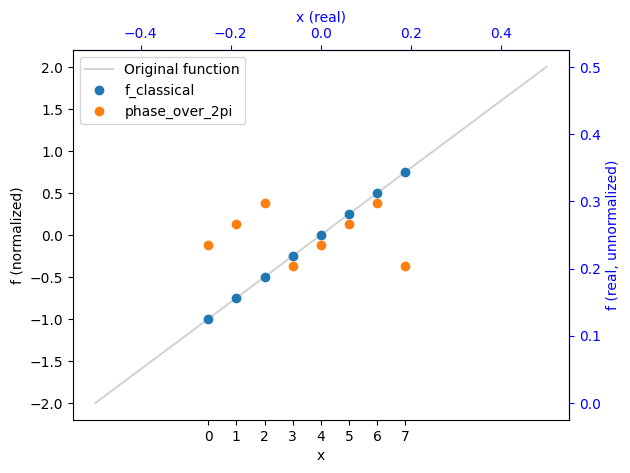

In [7]:
# Plot the results
plt.figure()
plot_classical()
simplified_df.plot(style='o', ax=plt.gca())
plt.legend()
plt.show()

But wait! The phase doesn't match the classical function!\
There are two reasons:
1. Wrapping of the phase around $2\pi$
2. A constant shift due to global phase

If we solve those two issues, we see that the phase exactly equal to the original function.

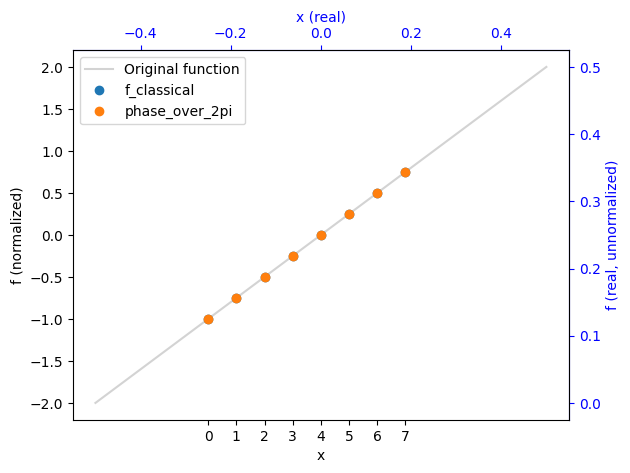

In [8]:
# 0. Simplify the dataframe - same as before
phases = np.angle(df["amplitude"]).astype(float)
phases_over_2pi = phases/(2*np.pi)
f_classical = f_normalized(df['x'])
simplified_df = pd.DataFrame({"f_classical": f_classical, "phase_over_2pi": phases_over_2pi.round(5)})
simplified_df.index = df['x']
simplified_df.sort_index(inplace=True)

# 1. Unwrap the phase
simplified_df['phase_over_2pi'] = np.unwrap(simplified_df['phase_over_2pi'], period=1)

# 2. Get rid of the global phase
simplified_df['phase_over_2pi'] -= simplified_df['phase_over_2pi'].iloc[N//2]
simplified_df['f_classical'] -= simplified_df['f_classical'].iloc[N//2]

# You can use the helper function:
# simplified_df = simplify_df(df)

# Plot the results
plt.figure()
plot_classical()
simplified_df.plot(style='o', ax=plt.gca())
plt.legend()
plt.show()

For convinience, the full code to generate this graph:

Circuit Width: 7
Circuit Depth: 30
Gate Counts: {'u': 35, 'cx': 27}


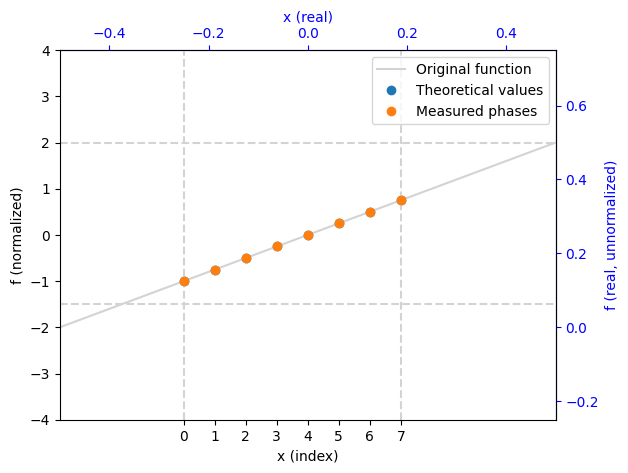

In [9]:
p = params()
# f(x) = 0.5*x + 0.25
# Gradient: f'(0) = 0.5
p.set_function(p.linear, (0.5, 0.25))
p.unpack()

@qfunc
def main(x: Output[QNum[n]], ancilla: Output[QNum[n0, SIGNED, n0]]):
    # 1. State preparation
    
    # 1.1. Set the coordinates state - Apply Hadamard gate on the coordinates register
    allocate(n, x)
    hadamard_transform(x)
    
    # 1.2. Set the ancilla state - Apply QFT to |1111...1> state
        # Note: the ancilla is a signed fractional number,
        # so the state |1111...1> corresponds to the value -1/N0
        # which is the most negative value
    numeric_value = -0.5**n0
    ancilla |= numeric_value
    qft(ancilla)

    # 1.3. Apply the function f on the ancilla, to create the phase kickback
    # Calculate the normalized f and add it to the ancilla
    val = f_normalized(x)
    inplace_add(val, ancilla)

    # 2. Next step in the algorithm: QFT inverse on the coordinates register
    # invert(lambda: qft(x))

df = run_statevector_simulation(main, print_circuit_info=True, filter_ancilla=True)
simplified_df = simplify_df(df)
plot_simplified_df(simplified_df)

## 2.2. Direct Phase

The phase kickback approach is good when we have a state-oracle, but in our simulation it is very unefficient.

Another approach is to directly prepare the wanted state.
In our case:
$$\sum_{\delta}e^{i2\pi\frac{N}{ml}f(\frac{l}{N}(\delta-\frac{N}{2}))}\ket\delta$$

Here we can see the same example using the prepare_complex_amplitudes function.\
You can look at the circuit width/depth and gate count to compare both methods.\
In real applications, both methods can be used, depending on the problem.

Circuit Width: 3
Circuit Depth: 5
Gate Counts: {'u': 3, 'cx': 4}


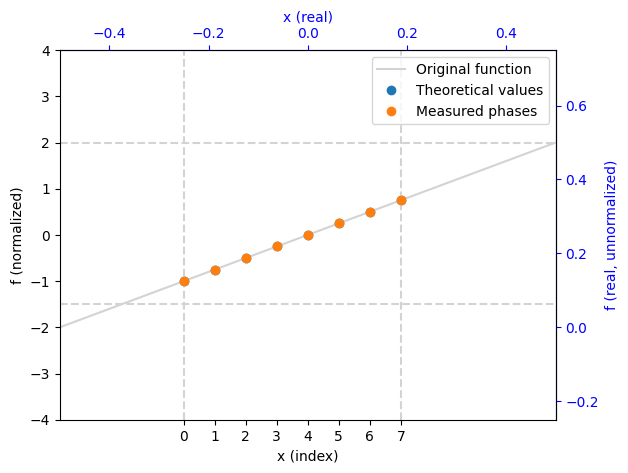

In [10]:
p = params()
# f(x) = 0.5*x + 0.25
# Gradient: f'(0) = 0.5
p.set_function(p.linear, (0.5, 0.25))
p.unpack()

@qfunc
def main(x: Output[QNum[n]]):
    # 1. State preparation
    
    # Now using the direct prepare_complex_amplitudes instead of the ancilla and the inplace_add
    x_array = np.arange(N) # Create an array of x values corresponding to the quantum states
    phases = f_normalized(x_array) * 2 * np.pi # Apply 2pi times the normalized function to get the phases
    magnitudes = np.ones(N) * 1 / N  # Set equal magnitudes for all states
    # You can use the helper function:
    # magnitudes, phases = p.calculate_magnitude_and_phase()

    prepare_complex_amplitudes(magnitudes=magnitudes, phases=phases, out=x)

    # 2. Next step in the algorithm: QFT inverse on the coordinates register
    # invert(lambda: qft(x))

df = run_statevector_simulation(main, print_circuit_info=True)
simplified_df = simplify_df(df)
plot_simplified_df(simplified_df)

The graph is exactly the same as the phase kickback method.\
From this point, we will use this method over the phase kickback, in order to have better efficiency.

## 2.3. Quadratic Function

More interesting are non-linear functions.\
In the next example we will see a quadratic function.\
Note that the 'magic' does not happen in this step. You will see that the phases agree with the function completly and doesn't do the linearization needed to calculate the gradient. The magic will happen in the next step where the QFT will do the linearization for us.

Circuit Width: 3
Circuit Depth: 12
Gate Counts: {'u': 8, 'cx': 6}


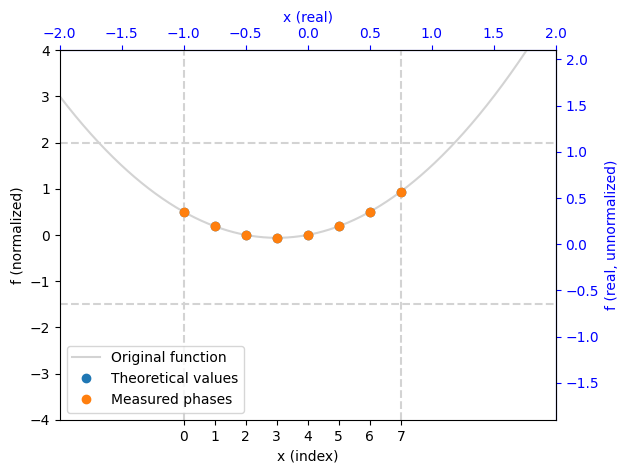

In [11]:
p = params()
# f(x) = 0.5*x^2 + 0.25*x + 0.1
# Gradient: f'(x) = x + 0.25, so f'(0) = 0.25
p.set_function(p.quadratic, (0.5, 0.25, 0.1))
p.l = 2
p.unpack()

@qfunc
def main(x: Output[QNum[n]]):
    # 1. State preparation
    magnitudes, phases = p.calculate_magnitude_and_phase()
    prepare_complex_amplitudes(magnitudes=magnitudes, phases=phases, out=x)

    # 2. Next step in the algorithm: QFT inverse on the coordinates register
    # invert(lambda: qft(x))
df = run_statevector_simulation(main, print_circuit_info=True)
simplified_df = simplify_df(df)
plot_simplified_df(simplified_df)

If we decrease $l$, we look at the function more closly, and it is closer to linear.

Circuit Width: 3
Circuit Depth: 12
Gate Counts: {'u': 8, 'cx': 6}


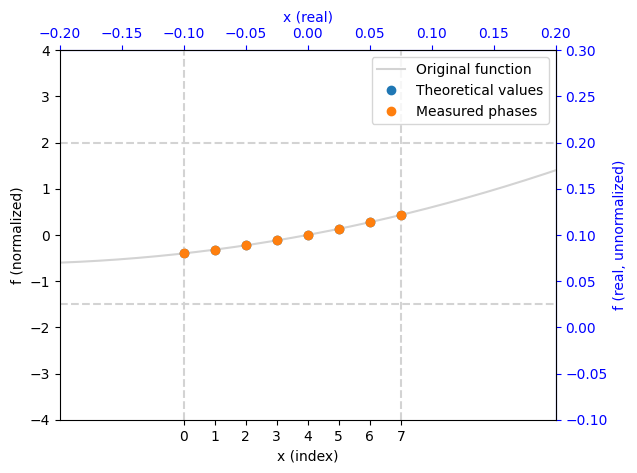

In [12]:
p = params()
# f(x) = 0.5*x^2 + 0.25*x + 0.1
# Gradient: f'(x) = x + 0.25, so f'(0) = 0.25
p.set_function(p.quadratic, (0.5, 0.25, 0.1))
p.l = 0.2
p.unpack()

@qfunc
def main(x: Output[QNum[n]]):
    # 1. State preparation
    magnitudes, phases = p.calculate_magnitude_and_phase()
    prepare_complex_amplitudes(magnitudes=magnitudes, phases=phases, out=x)

    # 2. Next step in the algorithm: QFT inverse on the coordinates register
    # invert(lambda: qft(x))
df = run_statevector_simulation(main, print_circuit_info=True)
simplified_df = simplify_df(df)
plot_simplified_df(simplified_df)

# 3. Full Algorithm

## 3.1. Linear Functions

The next and final step of the algorithm is to apply QFT on the coordinate.\
As discussed earlier, applying the QFT will automatically extract the gradient from the phases, and create a measurable state with the value of the gradient (normalized).

To see the full algorithm in action, we will switch from the statevector simulation to standard simulation, because the final result is acquired by a measurement and not by looking at the phases.

Let's start with a simple example of linear function.

Parsed counts: [{'x': 6}: 2048]
The analytical gradient is: -0.5
The majority gradient is: -0.5
The majority result is correct
####################################################
Success rate: 100.00% (2048/2048 shots)
[██████████████████████████████████████████████████] 100.00%


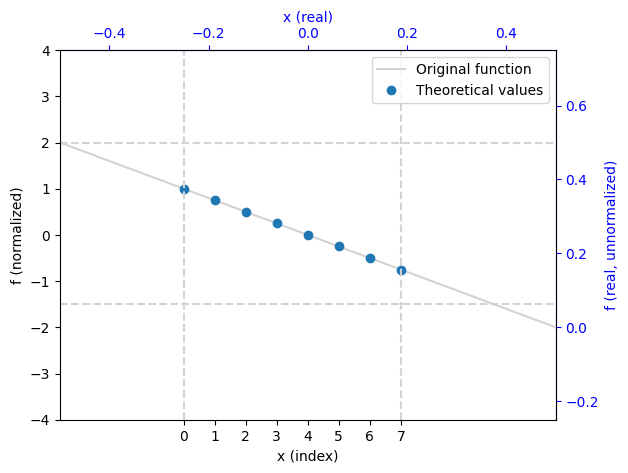

In [13]:
p = params()
p.set_function(p.linear, (-0.5, 0.25))
p.unpack()

@qfunc
def main(x: Output[QNum[n]]):
    # 1. State preparation
    magnitudes, phases = p.calculate_magnitude_and_phase()
    prepare_complex_amplitudes(magnitudes=magnitudes, phases=phases, out=x)

    # 2. QFT inverse on the coordinates register
    invert(lambda: qft(x))

qprog = synthesize(main)
job = execute(qprog)
# job.open_in_ide() # Uncomment to see the results in the IDE
pc = job.get_sample_result().parsed_counts

# You can use the helper function:
# pc = run_standard_simulation(main)

# Translate the majority state to a gradient value
majority_state = pc[0].state
value = majority_state.get('x')
# If the value is in the upper half of the range,
# it represents a negative value due to the modular arithmetic of the quantum states.
if value >= N//2:
    value -= N
# Divide by (N/m) to get the actual gradient value.
majority_gradient = value / (N/m)

# Or use the helper function:
# majority_gradient = state_to_gradient(majority_state.get('x'))

# Print the results and compute the majority gradient
print("Parsed counts:", pc)
print(f"The analytical gradient is: {p.analytical_gradient(0)}")
print(f"The majority gradient is: {majority_gradient}")

# Check if the majority result is correct within the resolution of the algorithm
resolution = m/N
is_correct = abs(majority_gradient - p.analytical_gradient(0)) < resolution/2
print(f"The majority result is", "correct" if is_correct else "incorrect")
print("####################################################")

# Compute the success rate of the algorithm, i.e. the percentage of shots that are correct within the resolution of the algorithm.
success_rate, success_shots, total_shots = compute_success_rate(pc, analytic_derivatives={'x': p.analytical_gradient(0)})
print(f"Success rate: {success_rate:.2%} ({success_shots}/{total_shots} shots)")
show_bar(success_rate)

# Visualize the theoretical values of the phases
# We used the standard simulation, so this is theoretical values only without the phases from the simulation
plot_theoretical()

# You can use the helper function:
# analyze_results(pc)

The result for the gradient is always a multiple of m/N.\
In the previous example, the gradient was -0.5, while the resolution (m/N) was 0.25.\
The gradient is a multiple of the resolution, and therefore the result can be exact, and the success rate was 100%.\
\
More complex case is where the gradient is not a multiple of the resolution.\
In those cases, the result will be a superposition of multiple solutions, but we can still get a good approximation for the gradient from the result.\
Let's see it in the next example.\
TODO: Consider removing this example, because it doesn't match the flow of the explaination.

Parsed counts: [{'x': 2}: 1755, {'x': 3}: 133, {'x': 1}: 63, {'x': 4}: 29, {'x': 5}: 20, {'x': 7}: 20, {'x': 0}: 19, {'x': 6}: 9]
The analytical gradient is: 0.55
The majority gradient is: 0.5
The majority result is correct
####################################################
Success rate: 85.69% (1755/2048 shots)
[███████████████████████████████████████████-------] 85.69%


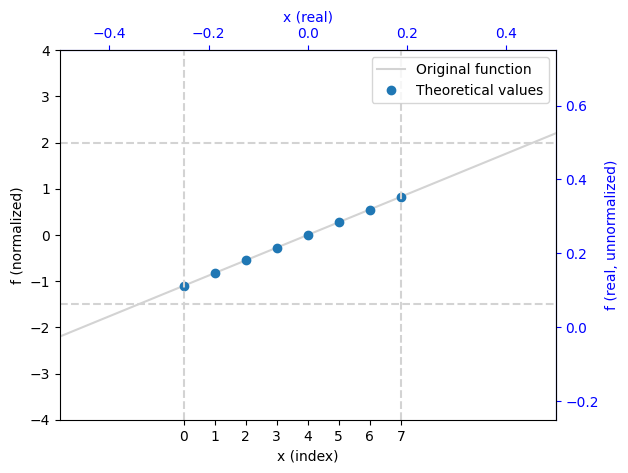

In [14]:
p = params()
# f(x) = 0.55*x + 0.25
# Gradient: f'(0) = 0.55
# Pay attention that 0.55 is not a multiple of m/N = 0.25,
# so we expect to get a superposition of multiple states around the correct gradient.
p.set_function(p.linear, (0.55, 0.25))
p.unpack()

@qfunc
def main(x: Output[QNum[n]]):
    # 1. State preparation
    magnitudes, phases = p.calculate_magnitude_and_phase()
    prepare_complex_amplitudes(magnitudes=magnitudes, phases=phases, out=x)

    # 2. QFT inverse on the coordinates register
    invert(lambda: qft(x))

pc = run_standard_simulation(main)
analyze_results(pc)

## 3.2. Quadratic Function

Again, let's try calculating the gradient of a non-linear function. In the next example, we will explore a quadratic function.\
In the case of non-linear function, we will need to cleverly choose the value of $l$ - the interval around the origin.\
In order for the algorithm to work, we need to work in the linear regime around the origin, so we need to choose small enough $l$.

First, for good selection of $l$, we see that the points are almost linear, and we get a good success rate.

Parsed counts: [{'x': 1}: 2013, {'x': 0}: 16, {'x': 2}: 15, {'x': 3}: 3, {'x': 5}: 1]
The analytical gradient is: 0.25
The majority gradient is: 0.25
The majority result is correct
####################################################
Success rate: 98.29% (2013/2048 shots)
[█████████████████████████████████████████████████-] 98.29%


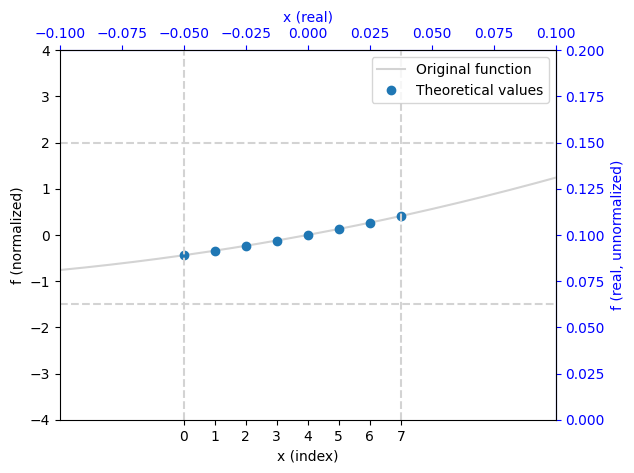

In [15]:
# In this example we will use the quadratic function
p = params()
# f(x) = 0.6*x^2 + 0.25*x + 0.1
# Gradient: f'(x) = 1.2*x + 0.25, so f'(0) = 0.25
p.set_function(p.quadratic, (0.6, 0.25, 0.1))
# Setting l properly, ensuring we are in the linear regime of the function.
p.l = 0.1
p.unpack()

@qfunc
def main(x: Output[QNum[n]]):
    # 1. State preparation
    magnitudes, phases = p.calculate_magnitude_and_phase()
    prepare_complex_amplitudes(magnitudes=magnitudes, phases=phases, out=x)

    # 2. QFT inverse on the coordinates register
    invert(lambda: qft(x))

pc = run_standard_simulation(main)
analyze_results(pc)

But if we increase $l$ outside of the linear regime, we see that the success rate get drasticly lower:

Parsed counts: [{'x': 0}: 501, {'x': 1}: 492, {'x': 2}: 484, {'x': 7}: 208, {'x': 3}: 184, {'x': 6}: 90, {'x': 4}: 46, {'x': 5}: 43]
The analytical gradient is: 0.25
The majority gradient is: 0.0
The majority result is incorrect
####################################################
Success rate: 24.02% (492/2048 shots)
[████████████--------------------------------------] 24.02%


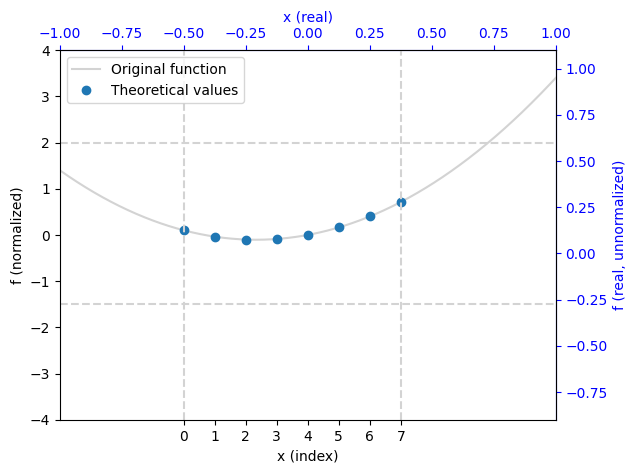

In [16]:
# In this example we will use the quadratic function
p = params()
# f(x) = 0.6*x^2 + 0.25*x + 0.1
# Gradient: f'(x) = 1.2*x + 0.25, so f'(0) = 0.25
p.set_function(p.quadratic, (0.6, 0.25, 0.1))
# Setting l to be too big, so we are outside of the linear regime of the function.
p.l = 1
p.unpack()

@qfunc
def main(x: Output[QNum[n]]):
    # 1. State preparation
    magnitudes, phases = p.calculate_magnitude_and_phase()
    prepare_complex_amplitudes(magnitudes=magnitudes, phases=phases, out=x)

    # 2. QFT inverse on the coordinates register
    invert(lambda: qft(x))

pc = run_standard_simulation(main)
analyze_results(pc)

# 4. Parameters Selection - TODO

We saw earlier the importance of proper selection of some of the parameters.\
Let's dive deeper into the parameters selection.

## 4.1. Understanding the parameters

There are three main parameters to be selected: $l$, $m$ and $n$.\
$n$ is the number of bits of the result. The bigger $n$, the higher the accuracy of the result.\
$l$ is the interval size around the origin ($dx$).\
$m/2$ is the maximal gradient that can be calculated (in absolute value).

For the parameter $l$, we saw earlier that it should be selected such that we look at the linear regime of the function. See section 2.2.

Understanding the parameter $m$ is a little trickier. We will look at a bounding box around the origin.\
The width of the box (dx) is $l$, spanning from $-l/2$ to $l/2$. The slope of the graph (dy/dx) is bounded between $-m/2$ to $m/2$. Therefore, the height of the box (dy) should be bounded dy/dx*dx, so the height should be $lm/2$, making the box span between $-lm/4$ to $lm/4$.\
When we plot the graph, if all the points are inside this box, then we know that the gradient is bounded by $m/2$ and we will get the correct result.\
If the points are outside this box, we will get aliasing in the results and get an incorrect gradient.\
Note that in our graphs we use the normalized function instead of the original function, so the box is between $-N/4$ to $N/4$ instead of $lm/4$.

We will see now the same function, once with correct selection of m and one with incorrect selection of $m$, and we can see that if $m$ is too small the theoretical values are out of the bounding box, and the phases from the simulation are folded into the box creating aliasing. 

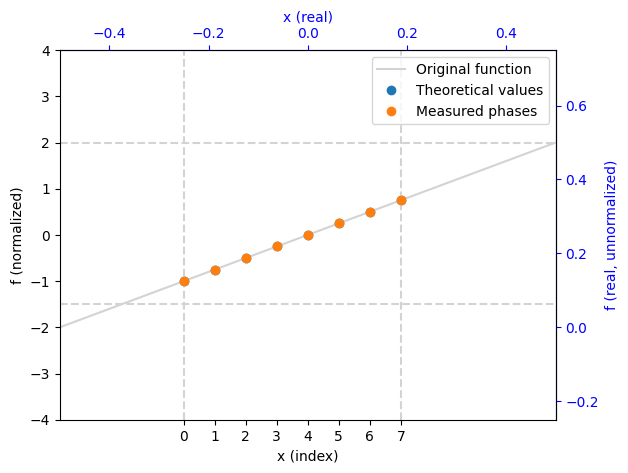

In [17]:
# In this example we will use the linear function
p = params()
p.set_function(p.linear, (0.5, 0.25))
p.m = 2 # Correct selection of m - no aliasing.
p.unpack()

@qfunc
def main(x: Output[QNum[n]]):
    magnitudes, phases = p.calculate_magnitude_and_phase()
    prepare_complex_amplitudes(magnitudes=magnitudes, phases=phases, out=x)

df = run_statevector_simulation(main, print_circuit_info=False)
simplified_df = simplify_df(df)
plot_simplified_df(simplified_df)
# simplified_df

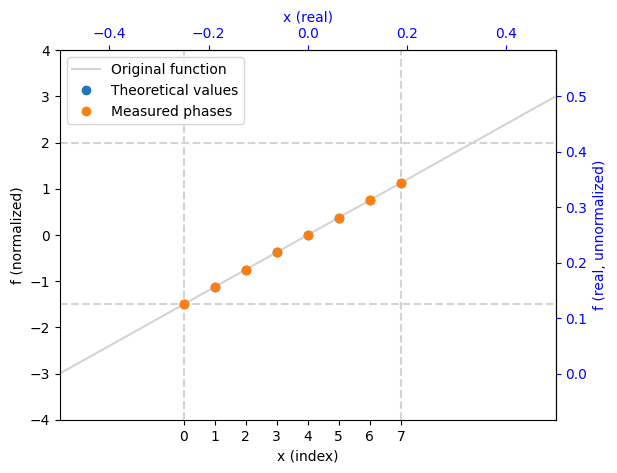

In [18]:
# In this example we will use the linear function
p = params()
p.set_function(p.linear, (0.5, 0.25))
p.m = 1.333 # Marginal selection of m - still no aliasing.
p.unpack()

@qfunc
def main(x: Output[QNum[n]]):
    magnitudes, phases = p.calculate_magnitude_and_phase()
    prepare_complex_amplitudes(magnitudes=magnitudes, phases=phases, out=x)

df = run_statevector_simulation(main, print_circuit_info=False)
simplified_df = simplify_df(df)
plot_simplified_df(simplified_df)
# simplified_df

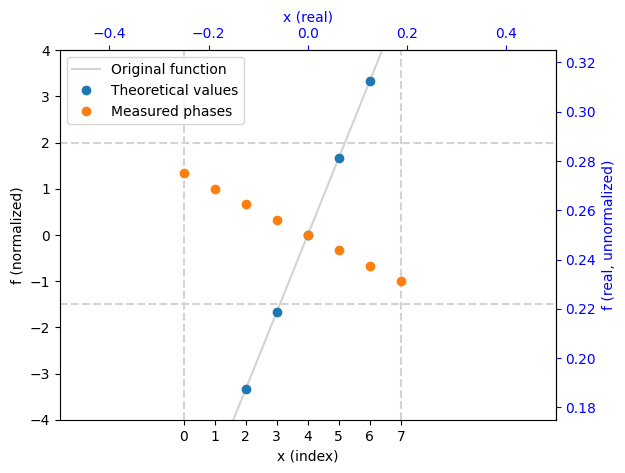

In [19]:
# In this example we will use the linear function
p = params()
p.set_function(p.linear, (0.5, 0.25))
p.m = 0.3 # Incorrect selection of m - aliasing occurs.
p.unpack()

@qfunc
def main(x: Output[QNum[n]]):
    magnitudes, phases = p.calculate_magnitude_and_phase()
    prepare_complex_amplitudes(magnitudes=magnitudes, phases=phases, out=x)

df = run_statevector_simulation(main, print_circuit_info=False)
simplified_df = simplify_df(df)
plot_simplified_df(simplified_df)
# simplified_df

## 4.2. Success rate as function of parameter selection
**TODO**: consider removing this part

We can plot the success rate as a function of the selected parameters.\
In the first example, we will have a quadratic function $f(x)=0.6x^2+0.25x+0.1$, $f'(0)=0.25$.\
We can plot the graph for different selections of m.\
We discussed earlier that $m/2$ is the bound for the gradient value, so we expect to have poor results for $m<0.5$, good results for $m>0.5$, until reaching $m=0.25N=4$, where the resolution won't be good enough for meaningful result.\
Note the oscillations in the sucess rate in the optimal region. This is due to the discrete values the algorithm can return. As we increase the number of bits $n$, the oscillations will be smaller.

m=0.05: Success rate = 0.00%
m=0.1: Success rate = 0.00%
m=0.3: Success rate = 0.00%
m=0.5: Success rate = 0.00%
m=0.55: Success rate = 0.00%
m=0.7: Success rate = 79.39%
m=0.8: Success rate = 80.62%
m=0.9: Success rate = 87.40%
m=1.0: Success rate = 95.17%
m=1.5: Success rate = 73.05%
m=2.0: Success rate = 98.19%
m=4.0: Success rate = 0.00%
m=6.0: Success rate = 0.00%
m=10.0: Success rate = 0.00%


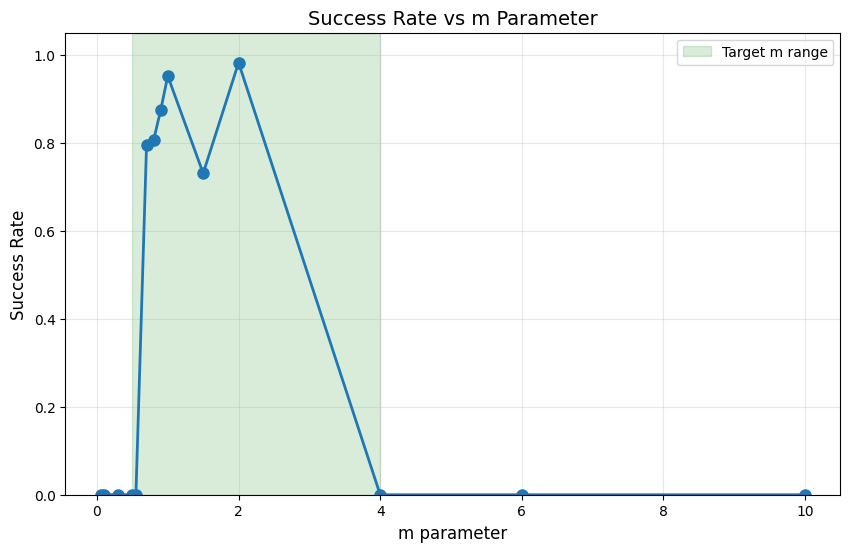

In [27]:
def plot_success_rate_vs_m(m_values, function, function_params, l_val=0.1, n_val=3):
    """
    Iterate over different m values and plot success rate as a function of m.

    Args:
        m_values: list of m values to test
        function: function name ("linear" / "quadratic") or callable
        function_params: parameters for the function
        l_val: l parameter (default 0.1)
        n_val: n parameter (default 3)
    """
    success_rates = []

    for m_val in m_values:
        p = params()
        p.m = m_val
        p.l = l_val
        p.n = n_val
        p.set_function(function, function_params)
        p.unpack()

        @qfunc
        def main(x: Output[QNum[n]]):
            magnitudes, phases = p.calculate_magnitude_and_phase()
            prepare_complex_amplitudes(magnitudes=magnitudes, phases=phases, out=x)
            invert(lambda: qft(x))

        pc = run_standard_simulation(main)
        analytic_grad = p.analytical_gradient(0)
        success_rate, _, _ = compute_success_rate(pc, analytic_derivatives={'x': analytic_grad}, reject_underresolution=True)
        success_rates.append(success_rate)
        print(f"m={m_val}: Success rate = {success_rate:.2%}")

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(m_values, success_rates, 'o-', linewidth=2, markersize=8)
    plt.xlabel('m parameter', fontsize=12)
    plt.ylabel('Success Rate', fontsize=12)
    plt.title('Success Rate vs m Parameter', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.ylim([0, 1.05])
    ax = plt.gca()
    ax.axvspan(0.5, 4.0, color='green', alpha=0.15, label='Target m range')
    ax.legend()
    plt.show()    
    return success_rates

# Example usage:
m_values = [0.05, 0.1, 0.3, 0.5, 0.55, 0.7, 0.8, 0.9, 1.0, 1.5, 2.0, 4.0, 6.0, 10.0]
results = plot_success_rate_vs_m(m_values, "quadratic", (0.6, 0.25, 0.1))

As for the $l$ parameter, we need to be in the linear regime, so we need to ensure $l$ is small enough, as can be seen in the next example:

l=0.1: Success rate = 94.19%
l=0.2: Success rate = 78.86%
l=0.3: Success rate = 60.84%
l=0.4: Success rate = 38.92%
l=0.5: Success rate = 23.05%
l=1: Success rate = 8.94%
l=1.5: Success rate = 15.62%
l=2.0: Success rate = 14.75%
l=3.0: Success rate = 28.37%
l=4.0: Success rate = 2.25%
l=5.0: Success rate = 24.37%


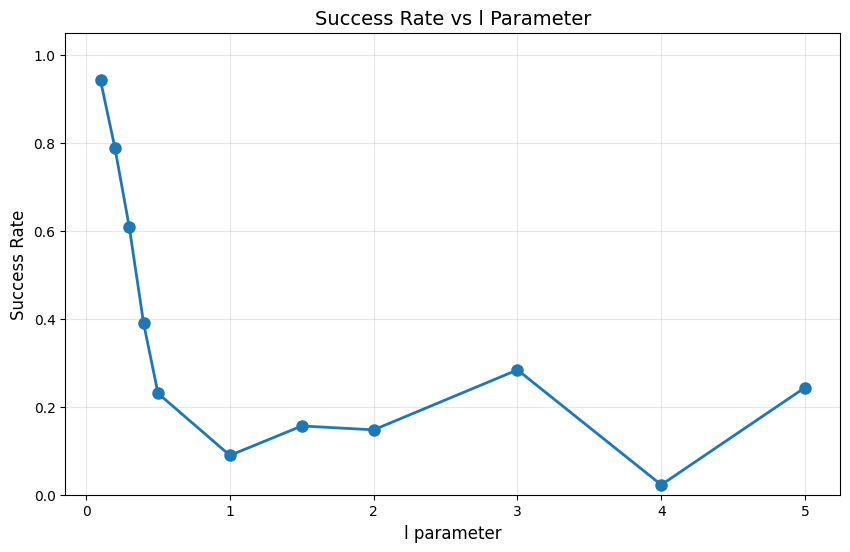

In [ ]:
def plot_success_rate_vs_l(l_values, function, function_params, m_val=2.0, n_val=3):
    """
    Iterate over different l values and plot success rate as a function of l.

    Args:
        l_values: list of l values to test
        function: function name ("linear" / "quadratic") or callable
        function_params: parameters for the function
        m_val: m parameter (default 1.0)
        n_val: n parameter (default 3)
    """
    success_rates = []

    for l_curr in l_values:
        p = params()
        p.m = m_val
        p.l = l_curr
        p.n = n_val
        p.set_function(function, function_params)
        p.unpack()

        @qfunc
        def main(x: Output[QNum[n]]):
            magnitudes, phases = p.calculate_magnitude_and_phase()
            prepare_complex_amplitudes(magnitudes=magnitudes, phases=phases, out=x)
            invert(lambda: qft(x))

        pc = run_standard_simulation(main)
        analytic_grad = p.analytical_gradient(0)
        success_rate, _, _ = compute_success_rate(pc, analytic_derivatives={"x": analytic_grad})
        success_rates.append(success_rate)
        print(f"l={l_curr}: Success rate = {success_rate:.2%}")

    plt.figure(figsize=(10, 6))
    plt.plot(l_values, success_rates, "o-", linewidth=2, markersize=8)
    plt.xlabel("l parameter", fontsize=12)
    plt.ylabel("Success Rate", fontsize=12)
    plt.title("Success Rate vs l Parameter", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.ylim([0, 1.05])
    plt.show()

    return success_rates


# Example usage:
l_values = [0.1, 0.2, 0.3, 0.4, 0.5, 1, 1.5, 2.0, 3.0]
results_l = plot_success_rate_vs_l(l_values, "quadratic", (0.6, 0.25, 0.1), m_val=1.0, n_val=3)

# 5. Multi-Coordinates Examples

This algorithm works in multiple dimensions too.\
We will now see an example in 2D, f(x,y).\
We will start with a linear and decoupled function $f(x,y)=ax+by+c$.

In [22]:
px = params()
py = params()

# Set the functions for x and y axes
# f(x, y) = a*x + b*y + c = 0.5*x - 0.25*y + 0.1
# df/dx = 0.5, df/dy = -0.25
a, b, c = 0.5, -0.25, 0.1
px.set_function(px.linear, (a, 0.0))
py.set_function(py.linear, (b, c))

# Use the globals from px. 
# Be careful - If you change the parameters in py you can not use the globals anymore!
px.unpack()

@qfunc
def main(x: Output[QNum[n]], y: Output[QNum[n]]):
    # State preparation for x-axis contribution
    magnitudes_x, phases_x = px.calculate_magnitude_and_phase()
    prepare_complex_amplitudes(magnitudes=magnitudes_x, phases=phases_x, out=x)

    # State preparation for y-axis contribution
    magnitudes_y, phases_y = py.calculate_magnitude_and_phase()
    prepare_complex_amplitudes(magnitudes=magnitudes_y, phases=phases_y, out=y)

    # Gradient extraction on each axis
    invert(lambda: qft(x))
    invert(lambda: qft(y))

pc = run_standard_simulation(main)
print(pc)

majority_state = pc[0].state
gx_true = px.analytical_gradient(0)
gy_true = py.analytical_gradient(0)

gx_meas = state_to_gradient(majority_state.get("x"))
gy_meas = state_to_gradient(majority_state.get("y"))

print(f"Analytical gradient: (dx, dy) = ({gx_true}, {gy_true})")
print(f"Majority gradient:   (dx, dy) = ({gx_meas}, {gy_meas})")

success_rate, success_shots, total_shots = compute_success_rate(
    pc, analytic_derivatives={"x": gx_true, "y": gy_true}
)
print(f"Success rate: {success_rate:.2%} ({success_shots}/{total_shots} shots)")
show_bar(success_rate)

[{'x': 2, 'y': 7}: 2048]
Analytical gradient: (dx, dy) = (0.5, -0.25)
Majority gradient:   (dx, dy) = (0.5, -0.25)
Success rate: 100.00% (2048/2048 shots)
[██████████████████████████████████████████████████] 100.00%


We can also have more complex example, with non-linear and coupled equation: $f(x, y)=ax^2+by^2+cxy+dx+ey+f$.

In [23]:
p = params()
p.l = 0.1
p.unpack()

def f(x, y):
    a, b, c, d, e, f = 0.6, -0.4, 0.25, 0.25, -0.5, 0.1
    global gradient_x, gradient_y
    gradient_x = d
    gradient_y = e
    return a * x**2 + b * y**2 + c * x * y + d * x + e * y + f

# Generated functions
def f_normalized(x, y):
    val = f(l / N * (x - N // 2), l / N * (y - N // 2))
    val *= N / (l * m)
    return val

@qfunc
def main(x: Output[QNum[n]], y: Output[QNum[n]]):
    # 1. State preparation
    x_array = np.arange(N) # Create an array of x values corresponding to the quantum states
    y_array = np.arange(N) # Create an array of y values corresponding to the quantum states
    
    # In order to use the prepare_complex_amplitudes function, we need to flatten the 2D arrays of magnitudes and phases into 1D arrays.
    X_grid, Y_grid = np.meshgrid(x_array, y_array, indexing='ij')
    phases_2d = f_normalized(X_grid, Y_grid) * 2 * np.pi
    magnitudes_2d = np.ones((N, N)) / N 
    phases_flat = phases_2d.flatten().tolist()
    magnitudes_flat = magnitudes_2d.flatten().tolist()
    
    # Prepare the state using the flattened arrays, then bind the combined register to the x and y registers.
    combined_reg = QNum("combined_reg")
    prepare_complex_amplitudes(
        magnitudes=magnitudes_flat, 
        phases=phases_flat, 
        out=combined_reg
    )
    bind(combined_reg, [y, x])

    # 2. Next step in the algorithm: QFT inverse on the coordinates register
    invert(lambda: qft(x))
    invert(lambda: qft(y))

pc = run_standard_simulation(main)
print(pc)

majority_state = pc[0].state
gx_true = gradient_x
gy_true = gradient_y

gx_meas = state_to_gradient(majority_state.get("x"))
gy_meas = state_to_gradient(majority_state.get("y"))

print(f"Analytical gradient: (dx, dy) = ({gx_true}, {gy_true})")
print(f"Majority gradient:   (dx, dy) = ({gx_meas}, {gy_meas})")

success_rate, success_shots, total_shots = compute_success_rate(
    pc, analytic_derivatives={"x": gx_true, "y": gy_true}
)
print(f"Success rate: {success_rate:.2%} ({success_shots}/{total_shots} shots)")
show_bar(success_rate)

[{'x': 1, 'y': 6}: 1992, {'x': 0, 'y': 6}: 14, {'x': 2, 'y': 6}: 14, {'x': 1, 'y': 5}: 8, {'x': 1, 'y': 7}: 6, {'x': 3, 'y': 6}: 3, {'x': 6, 'y': 6}: 2, {'x': 2, 'y': 7}: 1, {'x': 0, 'y': 3}: 1, {'x': 7, 'y': 1}: 1, {'x': 4, 'y': 6}: 1, {'x': 5, 'y': 4}: 1, {'x': 0, 'y': 7}: 1, {'x': 2, 'y': 5}: 1, {'x': 0, 'y': 5}: 1, {'x': 6, 'y': 7}: 1]
Analytical gradient: (dx, dy) = (0.25, -0.5)
Majority gradient:   (dx, dy) = (0.25, -0.5)
Success rate: 97.27% (1992/2048 shots)
[█████████████████████████████████████████████████-] 97.27%


# References

In [ ]:
# TODO: add